<a href="https://colab.research.google.com/github/kyunginstevenmin/ResNetFaceClassification/blob/main/ResNet%20Face%20Classification%20Implementation%20on%20Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet Face Classification with PyTorch

This notebook implements a ResNet model for face classification, based on the CMU 11-785 (Introduction to Deep Learning) course homework 2.

The dataset used for this task is available on the [Kaggle competition page](https://www.kaggle.com/competitions/11-785-f23-hw2p2-classification).

**Topics covered:**
- Building a CNN using PyTorch
- Loading and handling image datasets
- Image augmentation techniques
- Model training and optimization
- Tracking metrics (validation accuracy, training accuracy, learning rate) with WandB

## Table of Contents

1. Configurations
2. Classification Dataset
   - Dataset loading
   - Image augmentation
   - Data visualization
3. Model Architecture — ResNet-18
4. Training
   - Loss function and optimizer
   - Learning rate scheduling
   - WandB integration
   - Training loop
5. Model Performance

---
## 1. Configurations

In [1]:
!nvidia-smi # to see what GPU you have

zsh:1: command not found: nvidia-smi


In [ ]:
import torch
from torchsummary import summary
from torch import nn
from torch.nn import functional as F
import torchvision #This library is used for image-based operations (Augmentations)
import os
import gc
from tqdm import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import glob
import wandb
import matplotlib.pyplot as plt
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", DEVICE)

Device:  cpu


In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
config = {
    'batch_size': 64, # Increase this if your GPU can handle it
    'lr': 0.5,
    'epochs': 100,
    # Include other parameters as needed.
}

---
## 2. Classification Dataset

### Load Dataset & Configure Image Augmentation

In [ ]:
DATA_DIR    = 'data'# TODO: Path where you have downloaded the data
TRAIN_DIR   = os.path.join(DATA_DIR, "train")
VAL_DIR     = os.path.join(DATA_DIR, "dev")
TEST_DIR    = os.path.join(DATA_DIR, "test")


### Image Augmentation

Augmentation pipeline follows two sources:

**[He et al., 2018](https://arxiv.org/abs/1812.01187) — Bag of Tricks for Image Classification:**
- Convert image to raw pixels
- Horizontal flip with probability 0.5
- Color jitter (hue, saturation, brightness)
- Gaussian blur
- RGB channel normalization

Technical notes:
- Most torchvision transforms are done on PIL images. So you convert it into a tensor at the end with ToTensor(). But there are some transforms which are performed after ToTensor() : e.g - Normalization.
- Transform applied to training dataset vs validation dataset: only apply normalization to validation dataset using training mean and std. Because you want the validation dataset to be representative of the test dataset, and we will not apply image augmentation techniques to the test dataset.


#### Define Transforms

In [ ]:
# Transforms using torchvision - Refer https://pytorch.org/vision/stable/transforms.html
# mean and std per channel under current transformation techniques:
mean = [0.4289, 0.3656, 0.3335]
std = [0.2511, 0.2274, 0.2122]


train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomAffine(degrees=10,scale=(0.7,1.3),shear=10),
    torchvision.transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    torchvision.transforms.RandomGrayscale(),
    torchvision.transforms.GaussianBlur(kernel_size=(5,9), sigma=(0.1,5.)),

    torchvision.transforms.ToTensor()
    # torchvision.transforms.Normalize(mean,std)
])

valid_transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

#### Create Dataset and Dataloader
DataLoader
  → sampler picks random indices [42, 7, 391, ...]   (shuffle=True)

  → worker processes each call dataset[idx]

      → dataset.__getitem__(idx)

          → loads image

          → applies augs transform
          
          → returns (image_tensor, label)

  → DataLoader stacks batch_size results into one tensor

  → yields (batch_tensor, labels) to training loop

In [ ]:
train_dataset   = torchvision.datasets.ImageFolder(TRAIN_DIR, transform= train_transforms)
valid_dataset   = torchvision.datasets.ImageFolder(VAL_DIR, transform= valid_transforms)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    dataset     = train_dataset,
    batch_size  = config['batch_size'],
    shuffle     = True,
    num_workers = 4,
    pin_memory  = True
)
valid_loader = torch.utils.data.DataLoader(
    dataset     = valid_dataset,
    batch_size  = config['batch_size'],
    shuffle     = False,
    num_workers = 2
)

In [ ]:
from torch.utils.data import random_split
import os

def random_subset(dataset, fraction=0.20, seed=42):
    """Return a random fraction of dataset for Stage 1 (cheap elimination).
    Uses fixed seed so all head configs train on the identical 20% subset —
    ensuring differences in val accuracy reflect architecture, not data split."""
    n = int(len(dataset) * fraction)
    rest = len(dataset) - n
    subset, _ = random_split(dataset, [n, rest],
                             generator=torch.Generator().manual_seed(seed))
    return subset

# Stage 1: 20% of training data for fast elimination across head configs
stage1_dataset = random_subset(train_dataset, fraction=0.20)
stage1_loader  = torch.utils.data.DataLoader(stage1_dataset, batch_size=config['batch_size'],
                            shuffle=True,
                            num_workers=min(os.cpu_count() - 1, 8),
                            pin_memory=True)
print(f"Stage 1 subset: {len(stage1_dataset)} images ({len(stage1_dataset)/len(train_dataset)*100:.0f}% of training set)")


Stage 1 subset: 28004 images (20% of training set)


In [ ]:
# You can do this with ImageFolder as well, but it requires some tweaking
class ClassificationTestDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transforms):
        self.data_dir   = data_dir
        self.transforms = transforms
        self.img_paths  = list(map(lambda fname: os.path.join(self.data_dir, fname), sorted(os.listdir(self.data_dir)))) # This one-liner basically generates a sorted list of full paths to each image in the test directory: map returns an iterator that applies that lambda function to the sorted list of files in test directory. lambda joins the path of data_dir with each file names of test directory.

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        return self.transforms(Image.open(self.img_paths[idx]))

test_dataset = ClassificationTestDataset(TEST_DIR, transforms = valid_transforms) # Why are we using val_transforms for Test Data? Because we want to apply the same transformation, which is no transformation, to both validation and test data. We should have applied the normalization.
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = config['batch_size'], shuffle = False,
                         drop_last = False, num_workers = 2) # same config of test_loader and valid_loader

In [ ]:
print("Number of classes    : ", len(train_dataset.classes))
print("No. of train images  : ", train_dataset.__len__())
print("Shape of image       : ", train_dataset[0][0].shape)
print("Batch size           : ", config['batch_size'])
print("Train batches        : ", train_loader.__len__())
print("Val batches          : ", valid_loader.__len__())

Number of classes    :  7001
No. of train images  :  140020
Shape of image       :  torch.Size([3, 224, 224])
Batch size           :  64
Train batches        :  2188
Val batches          :  547


#### Normalization statistics from training dataset
Channel mean and std of the training dataset is used to normalize the training, validation, and test dataset.
This step calculates the channel mean and std of the training dataset.

In [11]:
# mean = 0
# std = 0
# nb_sample = 0.

# for img,_ in train_loader:
#   batch_sample = img.size(0)
#   img = img.view(batch_sample, img.size(1), -1) # resizes the image to batch_sample x channel x -1 : ie flatten the height and width dimensions into one dimension. This allows us to compute the mean and std across all pixels for each channel.
#   mean += img.mean(2).sum(0) # computes the mean across the pixel dimension (which is now the last dimension after flattening) for each channel and sums it up across the batch. This gives us the total sum of pixel means for each channel across all images in the batch.
#   std += img.std(2).sum(0) # compute the standard deviation in the same way
#   nb_sample += batch_sample

# mean /= nb_sample
# std /= nb_sample

### Data Visualization

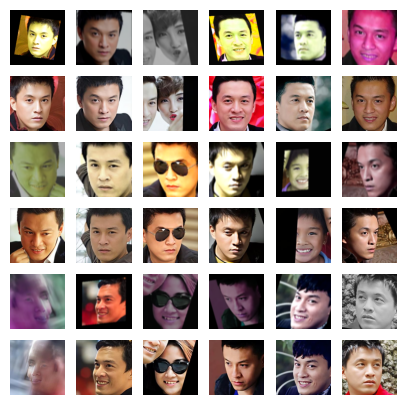

In [12]:
# Visualize a few images in the dataset
r, c    = [6, 6]
fig, ax = plt.subplots(r, c, figsize= (5, 5))

k       = 20
dtl1     = torch.utils.data.DataLoader(
    dataset     = torchvision.datasets.ImageFolder(TRAIN_DIR, transform= train_transforms),
    batch_size  = config['batch_size'],
    shuffle     = False,
)

dtl2 = torch.utils.data.DataLoader(
    dataset = torchvision.datasets.ImageFolder(TRAIN_DIR, transform = valid_transforms), # no transform
    batch_size = config['batch_size'],
    shuffle = False
)

for data1, data2 in zip(dtl1, dtl2):
    x1, y1 = data1
    x2, y2 = data2

    for i in range(0,r,2):
        for j in range(c):
            img1, img2 = x1[k].numpy().transpose(1, 2, 0), x2[k].numpy().transpose(1,2,0)

            ax[i, j].imshow(img1)
            ax[i, j].axis('off')

            ax[i+1, j].imshow(img2)
            ax[i+1, j].axis('off')
            k+=1
    break

del dtl1
del dtl2

---
## 3. Model Architecture — ResNet-18

This implements the ResNet architecture introduced by [He et al. (2016)](https://arxiv.org/abs/1512.03385), adapted from the [Dive into Deep Learning, Chapter 8](https://d2l.ai/chapter_convolutional-modern/resnet.html).

#### ResNet-18 has 18 weight layers (layers with learnable parameters).                                 
                                                                                                     
  Specifically:                                                                                      
  - 1 initial conv layer
  - 16 conv layers inside the residual blocks (4 stages × 2 blocks × 2 conv layers)                  
  - 1 fully connected layer at the end                                                               
                                                                                                     
  = 18 total                                                                                         
                                                                                                     
  The residual blocks are grouped into 4 stages with increasing channels:                            
                                                                                                     
| Stage   | Blocks | Conv Layers per block | Output Channels |                                               
  |---------|--------|-------------|-----------------|                                               
  | Stage 1 | 2      | 2           | 64              |                                               
  | Stage 2 | 2      | 2           | 128             |                                               
  | Stage 3 | 2      | 2           | 256             |                                               
  | Stage 4 | 2      | 2           | 512             |

The `ResidualBlock` below is the core building block reused throughout the network. It applies two convolutional layers with a skip connection that adds the input directly to the output.

In [13]:
class Residual(nn.Module):
  """Base Residual layer"""
  def __init__(self, num_channels, use_1x1conv=False,kernel_sizes=3, strides=1):
    super().__init__()
    self.conv1 = nn.LazyConv2d(out_channels=num_channels, kernel_size=kernel_sizes, stride=strides, padding = ((kernel_sizes-1)//2))
    self.conv2 = nn.LazyConv2d(out_channels=num_channels, kernel_size=kernel_sizes, stride=1, padding=((kernel_sizes-1)//2))

    if use_1x1conv:
      self.conv3 = nn.LazyConv2d(out_channels=num_channels, kernel_size=1, stride=strides)
    else:
      self.conv3 = None

    self.bn1 = nn.LazyBatchNorm2d()
    self.bn2 = nn.LazyBatchNorm2d()


  def forward(self,x):
    Y = self.conv1(x)
    Y = self.bn1(Y)
    Y = F.relu(Y)
    Y = self.bn2(self.conv2(Y))

    if self.conv3: # transformation for identity connection if downsampling, or matching num channels of residual and identity
      x = self.conv3(x)

    Y += x # add residual and identity
    return F.relu(Y)




In [14]:
# simple test of Residual Class
residual = Residual(11,strides=5, use_1x1conv=True)
x = torch.rand(size=(1,3,10,10))
Y = residual(x)
Y.shape

torch.Size([1, 11, 2, 2])

In [15]:
# MLP Head Configs — used to select architecture for each experiment run
# Each hidden layer: Linear(bias=False) -> BatchNorm1d -> ReLU -> Dropout
# Final layer: Linear (no activation — raw logits for CrossEntropyLoss)
HEAD_CONFIGS = {
    'A': {'hidden_dims': [],           'dropout': 0.4},  # baseline: 512 -> 7000
    'B': {'hidden_dims': [1024],       'dropout': 0.4},  # wider:    512 -> 1024 -> 7000
    'C': {'hidden_dims': [512],        'dropout': 0.4},  # same:     512 -> 512  -> 7000
    'D': {'hidden_dims': [1024, 512],  'dropout': 0.4},  # two-layer:512 -> 1024 -> 512 -> 7000
}

class MLPHead(nn.Module):
    def __init__(self, in_features, hidden_dims, num_classes, dropout=0.4):
        super().__init__()
        layers = []
        current_dim = in_features
        for hidden_dim in hidden_dims:
            layers += [
                nn.Linear(current_dim, hidden_dim, bias=False),  # bias=False: BN subsumes it
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout),
            ]
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, num_classes))  # no activation: raw logits
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


In [16]:
class ResNet(nn.Module):
  def b1(self):
    """This is an attribute of Network that will return the stem layer."""
    return nn.Sequential(
        nn.LazyConv2d(out_channels=64,kernel_size=7, stride=2),
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2)
    )

  def block(self, num_residuals, num_channels, first_block=False):
    """Single block has multiple residual units, all with the same number of channels.

    The first unit is indicated has use_1x1conv = True for two reasons.
    1) Match the number of channels of input X and the output of the residuals.
    2) Downsampling is done in first unit. therefore, stride=2.

    num_residuals -- number of residual units in one block.
    num_channels -- number of channels for every residual unit is the same.
    first_block -- Set to True only first 1st Residual block of network, so that we don't down sample.
    """
    blk = []
    for i in range(num_residuals):
      if i == 0 and first_block == False:
        blk.append(Residual(num_channels=num_channels, use_1x1conv=True, strides=2))
      else:
        blk.append(Residual(num_channels=num_channels))
    return nn.Sequential(*blk)

  def __init__(self, arch, lr=0.1, num_classes=7000, head=None, num_features=512):
    super(ResNet, self).__init__()
    self.net = nn.Sequential(self.b1()) # stem module
    for i, b in enumerate(arch):
      self.net.add_module(name=f'b{i+2}', module=self.block(num_residuals=b[0], num_channels=b[1], first_block=(i==0)))

    # Pooling + flatten only — no classifier here
    self.net.add_module(name='last', module=nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
    ))

    # Separate head attribute for easy freezing
    if head is None:
        head = MLPHead(num_features, hidden_dims=[], num_classes=num_classes)
    self.head = head
    # NOTE: no Softmax — forward always returns raw logits.
    # CrossEntropyLoss expects raw logits and applies log-softmax internally.

  def forward(self, x, return_feats=False):
    """Forward propagation. Always returns raw logits.
    return_feats parameter kept for API compatibility with existing training loop calls."""
    feats = self.net(x)
    logits = self.head(feats)
    return logits


In [17]:
class ResNet18(ResNet):
  def __init__(self, lr=0.1, num_classes=7001, head=None):
    super().__init__(((2, 64), (2, 128), (2, 256), (2, 512)), head=head, num_classes=num_classes)


In [18]:
def freeze_backbone(model):
    """Freeze all parameters except model.head. Called once before training.
    Backbone stays frozen for the entire experiment — it was trained on the same
    dataset, so its features are already well-aligned with the 7000-class task."""
    for param in model.parameters():
        param.requires_grad_(False)
    for param in model.head.parameters():
        param.requires_grad_(True)


def load_backbone_only(checkpoint_path, model, device):
    """Load backbone weights from the existing baseline checkpoint.

    The baseline checkpoint uses the OLD ResNet architecture where the classifier
    is embedded inside net.last as a Sequential:
      net.last.0  -> AdaptiveAvgPool2d  (no params)
      net.last.1  -> Flatten            (no params)
      net.last.2  -> LazyLinear         (params to EXCLUDE)

    Checkpoint key is 'model_state_dict' — matches the existing notebook save format.

    Verify exact key names before running:
      ckpt = torch.load('checkpoint.pth', map_location='cpu', weights_only=True)
      for k in ckpt['model_state_dict'].keys():
          print(k)
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    saved_state = checkpoint['model_state_dict']

    # Exclude net.last.2 (LazyLinear in old architecture)
    backbone_state = {k: v for k, v in saved_state.items()
                      if not k.startswith('net.last.2')}

    missing, unexpected = model.load_state_dict(backbone_state, strict=False)
    if unexpected:
        print(f"Warning: ignoring {len(unexpected)} unexpected keys: {unexpected[:5]}")
    print(f"Backbone loaded. New head randomly initialized ({len(missing)} keys).")


In [19]:
# ── Load backbone from best baseline checkpoint, then freeze it ──────────────
# Set BASELINE_CKPT_PATH to the path of your best trained baseline model.
BASELINE_CKPT_PATH = 'checkpoints/checkpoint.pth'  # update to your actual path

load_backbone_only(BASELINE_CKPT_PATH, model, DEVICE)
freeze_backbone(model)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


NameError: name 'model' is not defined

In [ ]:
# Select head config for this experiment run
# Change HEAD_CONFIG before running wandb.init cell to switch experiments
HEAD_CONFIG = 'A'  # 'A' (baseline), 'B' (wider), 'C' (same-width), 'D' (two-layer)

head  = MLPHead(512, **HEAD_CONFIGS[HEAD_CONFIG], num_classes=7001)
model = ResNet18(head=head).to(DEVICE)
summary(model, (3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 109, 109]           9,472
       BatchNorm2d-2         [-1, 64, 109, 109]             128
              ReLU-3         [-1, 64, 109, 109]               0
         MaxPool2d-4           [-1, 64, 54, 54]               0
            Conv2d-5           [-1, 64, 54, 54]          36,928
       BatchNorm2d-6           [-1, 64, 54, 54]             128
            Conv2d-7           [-1, 64, 54, 54]          36,928
       BatchNorm2d-8           [-1, 64, 54, 54]             128
          Residual-9           [-1, 64, 54, 54]               0
           Conv2d-10           [-1, 64, 54, 54]          36,928
      BatchNorm2d-11           [-1, 64, 54, 54]             128
           Conv2d-12           [-1, 64, 54, 54]          36,928
      BatchNorm2d-13           [-1, 64, 54, 54]             128
         Residual-14           [-1, 64,

In [ ]:
print(sum(p.numel() for p in model.head.parameters()))

3591513


---
## 4. Training

### Training Configuration

| Setting | Choice |
|---|---|
| Optimizer | SGD |
| LR Schedule | CosineAnnealing with warmup |
| Weight initialization | Xavier (Glorot) |
| Loss Function | Cross-entropy Loss |

#### Learning Rate, Batch Size, and Epochs

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
scaler    = torch.amp.GradScaler() # for mixed precision autocast

# Optimizer trains head parameters only — backbone is frozen throughout
# (backbone was trained on same dataset, features already well-aligned with task)
optimizer = torch.optim.SGD(
    model.head.parameters(),
    lr=config['lr'], momentum=0.9, weight_decay=1e-4
)


/var/folders/px/2xtvn_m102g65bj6dwxqx3c00000gn/T/ipykernel_5475/3733750177.py:2: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler    = torch.amp.GradScaler() # for mixed precision autocast


In [ ]:
len(train_loader)

2188

In [ ]:
@torch.no_grad()
def topk_accuracy(logits, targets, topk=(1, 5)):
    """Compute top-k accuracy for each k in topk.

    Args:
        logits:  Raw model output, shape (N, C).
        targets: Ground-truth class indices, shape (N,).
        topk:    Tuple of k values to compute.

    Returns:
        List of scalar tensors, one per k, each in [0, 100].
    """
    maxk = max(topk)           # largest k — e.g. 5
    batch_size = targets.size(0)

    # pred: (N, maxk) — indices of top-maxk predictions per sample
    _, pred = logits.topk(maxk, dim=1, largest=True, sorted=True)
    pred = pred.t()            # (maxk, N) — each row is a rank

    # correct[r, n] = True if rank-r prediction for sample n matches true label
    correct = pred.eq(targets.unsqueeze(0))

    results = []
    for k in topk:
        # any() across top-k ranks: did ANY of top-k predictions match?
        correct_k = correct[:k].any(dim=0).float().sum()
        results.append(correct_k * (100.0 / batch_size))
    return results


In [ ]:
def train(model, dataloader, optimizer, criterion):
  model.train() # sets applicable training modules to training mode: ex) BN, dropout

  # progress bar
  batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0,
                   desc='Train', ncols=5)

  running_loss, running_top1, running_top5, n = 0.0, 0.0, 0.0, 0

  for i, (images, labels) in enumerate(dataloader):

    optimizer.zero_grad()
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    with torch.cuda.amp.autocast(): # auto mixed precision
      outputs = model(images, return_feats=True) # returns raw logits (CrossEntropyLoss expects logits)
      loss = criterion(outputs, labels)

    top1, top5 = topk_accuracy(outputs, labels, topk=(1, 5))
    bs = images.size(0)
    running_loss += loss.item() * bs
    running_top1 += top1.item() * bs
    running_top5 += top5.item() * bs
    n += bs

    batch_bar.set_postfix(
        top1  = "{:.04f}%".format(running_top1 / n),
        loss  = "{:.04f}".format(running_loss / n),
        num_correct = int(running_top1 * n / 100),
        lr    = "{:.04f}".format(float(optimizer.param_groups[0]['lr']))
    )

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step() # per-batch step

    batch_bar.update()

  batch_bar.close()

  epoch_loss = running_loss / n
  epoch_top1 = running_top1 / n  # 1b fix: weighted by actual sample count
  epoch_top5 = running_top5 / n

  return epoch_top1, epoch_loss, epoch_top5


In [ ]:
def validate(model, dataloader, criterion):
  model.eval() # 1a fix: was model.train() — BN and Dropout must be disabled during validation

  # progress bar
  batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0,
                   desc='val', ncols=5)

  running_loss, running_top1, running_top5, n = 0.0, 0.0, 0.0, 0

  for i, (images, labels) in enumerate(dataloader):

    images, labels = images.to(DEVICE), labels.to(DEVICE)

    with torch.inference_mode():
      outputs = model(images, return_feats=True) # raw logits
      loss = criterion(outputs, labels)

    top1, top5 = topk_accuracy(outputs, labels, topk=(1, 5))
    bs = images.size(0)
    running_loss += loss.item() * bs
    running_top1 += top1.item() * bs
    running_top5 += top5.item() * bs
    n += bs

    batch_bar.set_postfix(
        top1 = "{:.04f}%".format(running_top1 / n),
        top5 = "{:.04f}%".format(running_top5 / n),
        loss = "{:.04f}".format(running_loss / n),
        num_correct = int(running_top1 * n / 100)
    )

    batch_bar.update()

  batch_bar.close()

  epoch_loss = running_loss / n
  epoch_top1 = running_top1 / n  # 1b fix: weighted by actual sample count
  epoch_top5 = running_top5 / n

  return epoch_top1, epoch_loss, epoch_top5


In [ ]:
gc.collect()
torch.cuda.empty_cache()

: 

### WandB Logging

[Weights & Biases (WandB)](https://wandb.ai) is used to track training metrics in real time, including training loss, validation accuracy, and learning rate.

In [ ]:
wandb.login(key=os.getenv("WANDB_API_KEY")) #API Key is in your wandb account, under settings (wandb.ai/settings)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/kyunginmin/.netrc
wandb: Currently logged in as: kyunginstevenmin (kyungin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Set experiment config — change HEAD_CONFIG to run different experiments
HEAD_CONFIG = 'A'  # 'A' (baseline), 'B' (wider), 'C' (same-width), 'D' (two-layer)
STAGE = 1          # 1 = 20% data (elimination), 2 = full data (selection)

run = wandb.init(
    name    = f"head-{HEAD_CONFIG}-stage{STAGE}",
    reinit  = 'finish_previous',
    project = "hw2p2-ablations",
    config  = {
        **config,
        'head_config':  HEAD_CONFIG,
        'hidden_dims':  HEAD_CONFIGS[HEAD_CONFIG]['hidden_dims'],
        'dropout':      HEAD_CONFIGS[HEAD_CONFIG]['dropout'],
        'stage':        STAGE,
    }
)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


### Learning Rate Scheduling

A linear **warmup period** followed by **CosineAnnealing** is used to stabilize early training and then smoothly decay the learning rate.

In [ ]:
# Choose dataloader based on stage
train_loader_exp = stage1_loader if STAGE == 1 else train_loader

# Short warmup (half epoch) -> CosineAnnealingLR for remaining steps
# Warmup stabilizes the randomly-initialized head at lr=0.5 before full LR kicks in
warmup_steps  = len(train_loader_exp) // 2
total_steps   = config['epochs'] * len(train_loader_exp)

scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps - warmup_steps)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, [scheduler_warmup, scheduler_cosine], milestones=[warmup_steps])

print(f"Warmup steps: {warmup_steps} | Total steps: {total_steps}")
print(f"Training on {'20% subset' if STAGE == 1 else 'full dataset'} ({len(train_loader_exp)} batches/epoch)")


Warmup steps: 219 | Total steps: 43800
Training on 20% subset (438 batches/epoch)


In [ ]:
scheduler.state_dict()

{'_milestones': [219],
 'last_epoch': 0,
 '_last_lr': [0.05],
 '_schedulers': [{'start_factor': 0.1,
   'end_factor': 1.0,
   'total_iters': 219,
   'base_lrs': [0.5],
   'last_epoch': 0,
   '_step_count': 1,
   '_is_initial': False,
   '_get_lr_called_within_step': False,
   '_last_lr': [0.05]},
  {'T_max': 43581,
   'eta_min': 0.0,
   'base_lrs': [0.5],
   'last_epoch': -1,
   '_step_count': 1,
   '_is_initial': False,
   '_get_lr_called_within_step': False,
   '_last_lr': [0.05]}]}

### Training Loop

In [52]:
best_valacc  = 0.0
ckpt_path    = './checkpoint.pth'
best_path    = './best.pth'

for epoch in range(config['epochs']):

    curr_lr = float(optimizer.param_groups[0]['lr'])

    train_top1, train_loss, train_top5 = train(model, train_loader_exp, optimizer, criterion)

    print("\nEpoch {}/{}: \nTrain Top-1 {:.04f}%\t Train Top-5 {:.04f}%\t Train Loss {:.04f}\t LR {:.04f}".format(
        epoch + 1, config['epochs'], train_top1, train_top5, train_loss, curr_lr))

    val_top1, val_loss, val_top5 = validate(model, valid_loader, criterion)

    print("Val Top-1 {:.04f}%\t Val Top-5 {:.04f}%\t Val Loss {:.04f}".format(
        val_top1, val_top5, val_loss))

    wandb.log({
        'train/loss':     train_loss,
        'train/top1_acc': train_top1,
        'train/top5_acc': train_top5,
        'val/loss':       val_loss,
        'val/top1_acc':   val_top1,
        'val/top5_acc':   val_top5,
        'learning_rate':  curr_lr,
        'epoch':          epoch,
    })

    # Always save latest checkpoint — used for spot resume
    checkpoint = {
        'epoch':              epoch,
        'model_state_dict':   model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict':  scaler.state_dict(),
        'val_acc':            val_top1,
    }
    torch.save(checkpoint, ckpt_path)

    # Save best model separately — used for Stage 2 and final evaluation
    if val_top1 >= best_valacc:
        print("Saving best model")
        torch.save(checkpoint, best_path)
        best_valacc = val_top1
        wandb.save(best_path)

run.finish()


Train:   0%|          | 0/438 [00:00<?, ?it/s]/Users/kyunginmin/my-data-project/ResNetFaceClassification/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/px/2xtvn_m102g65bj6dwxqx3c00000gn/T/ipykernel_5475/874065684.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # auto mixed precision
/Users/kyunginmin/my-data-project/ResNetFaceClassification/.venv/lib/python3.13/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Train:  73%|███████▎  | 321/438 [18:29<06:45,  3.47s/it, loss=19.3270, lr=0.5000, num_correct=61632, top1=0.0146%]

IndexError: Target 7000 is out of bounds.

### Inference — Test Set Predictions

In [ ]:
def test(model, dataloader):
  """Inference mode of model.

  Returns the model inference result Y for entire data as saved in dataloader as a list.
  """
  model.eval() # sets model to evaluation mode. for BN and dropout etc
  batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Test')
  test_results = []

  for i, (images, labels) in enumerate(dataloader):
    images =images.to(DEVICE)

    with torch.inference_mode(): # better performance. like no_grad()
      outputs = model(images, return_feats=False)
    outputs = torch.argmax(outputs, axis=1).detach().cpu().numpy().tolist()
    test_results.extend(outputs)

    batch_bar.update()

    break
  batch_bar.close()
  return test_results


In [ ]:
test(model, test_loader)

[1337,
 6641,
 5639,
 5324,
 5453,
 4748,
 2157,
 254,
 6457,
 6761,
 6715,
 3376,
 2326,
 983,
 6936,
 5222,
 792,
 4931,
 4212,
 4500,
 4093,
 1290,
 4183,
 2198,
 652,
 2466,
 3180,
 686,
 4221,
 6334,
 5738,
 4462,
 5857,
 4223,
 5274,
 5143,
 4744,
 5955,
 5185,
 6833,
 4582,
 3222,
 5224,
 1285,
 2399,
 5414,
 6324,
 5542,
 350,
 279,
 1732,
 1917,
 5561,
 3717,
 1529,
 492,
 5928,
 5358,
 4112,
 1700,
 4250,
 4564,
 4970,
 3858]

---
## 5. Model Performance

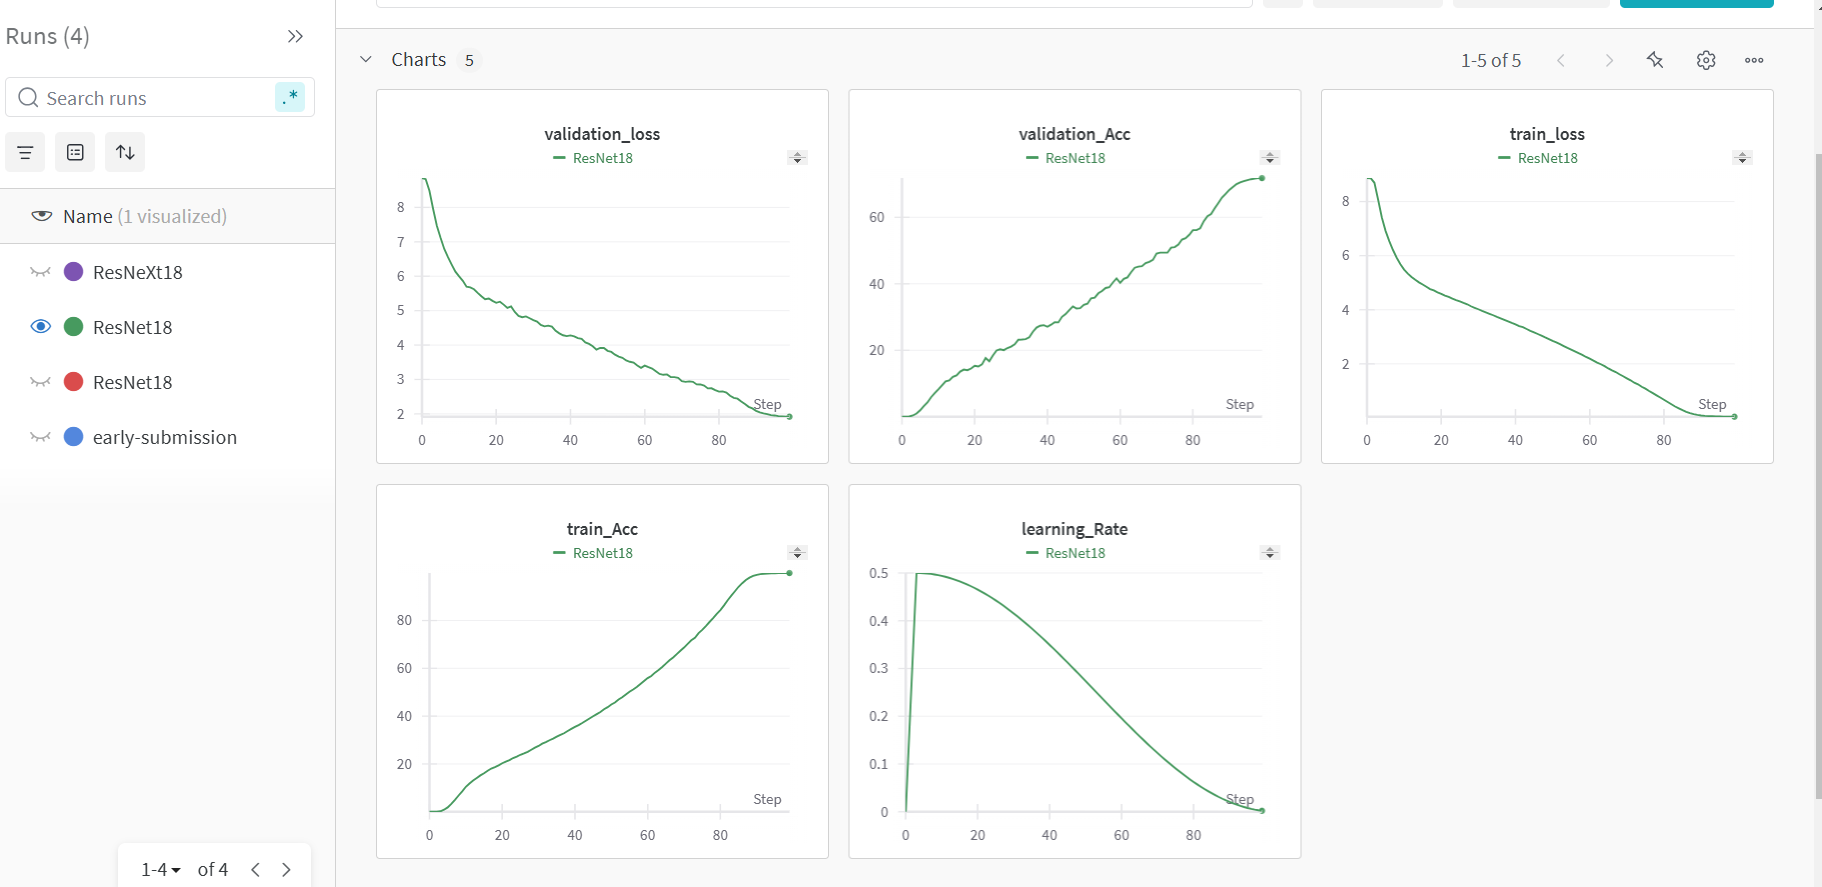